<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/MultiHorizonXGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating lag features...
Applying log transform...

TRAINING MODEL FOR 1-DAY FORECAST
Training...
Predicting...

METRICS

CountofGroup
MAE       : 7.57
SMAPE     : 3.33%
ACCURACY  : 96.67%

CountofClientName
MAE       : 7.76
SMAPE     : 3.52%
ACCURACY  : 96.48%

CountofAccountID
MAE       : 7.57
SMAPE     : 3.33%
ACCURACY  : 96.67%

CountofCreditOfficerID
MAE       : 7.57
SMAPE     : 3.33%
ACCURACY  : 96.67%

SumofPrincipalOutstanding
MAE       : 243,336.56
SMAPE     : 3.81%
ACCURACY  : 96.19%

SumofInterestOutstanding
MAE       : 67,572.03
SMAPE     : 5.09%
ACCURACY  : 94.91%

SumofTotalPrincipalOverdue
MAE       : 69,054.66
SMAPE     : 2.48%
ACCURACY  : 97.52%

SumofTotalInterestOverdue
MAE       : 17,055.13
SMAPE     : 2.92%
ACCURACY  : 97.08%

SumofTotalPAR
MAE       : 243,336.56
SMAPE     : 3.81%
ACCURACY  : 96.19%

Generating future forecasts...


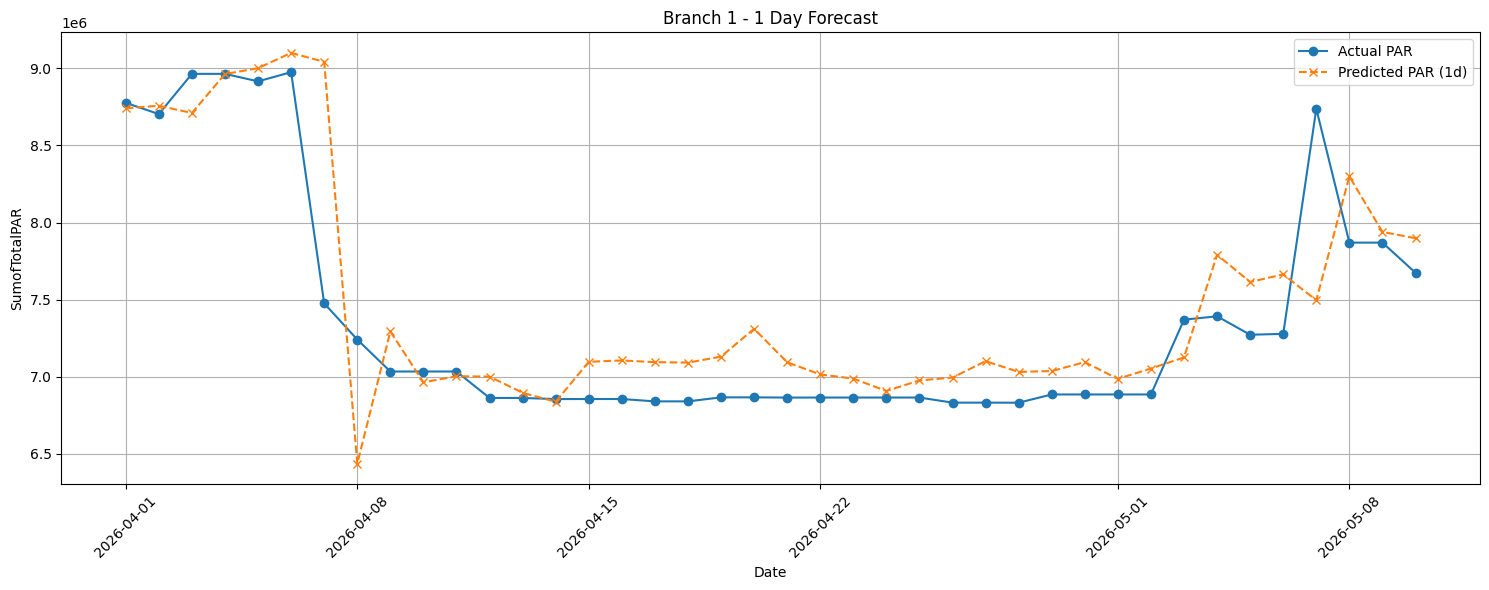


TRAINING MODEL FOR 7-DAY FORECAST
Training...
Predicting...

METRICS

CountofGroup
MAE       : 21.54
SMAPE     : 7.29%
ACCURACY  : 92.71%

CountofClientName
MAE       : 21.45
SMAPE     : 7.59%
ACCURACY  : 92.41%

CountofAccountID
MAE       : 21.54
SMAPE     : 7.29%
ACCURACY  : 92.71%

CountofCreditOfficerID
MAE       : 21.54
SMAPE     : 7.29%
ACCURACY  : 92.71%

SumofPrincipalOutstanding
MAE       : 534,683.60
SMAPE     : 7.51%
ACCURACY  : 92.49%

SumofInterestOutstanding
MAE       : 124,095.64
SMAPE     : 9.10%
ACCURACY  : 90.90%

SumofTotalPrincipalOverdue
MAE       : 209,217.53
SMAPE     : 5.41%
ACCURACY  : 94.59%

SumofTotalInterestOverdue
MAE       : 40,170.11
SMAPE     : 5.12%
ACCURACY  : 94.88%

SumofTotalPAR
MAE       : 534,683.60
SMAPE     : 7.51%
ACCURACY  : 92.49%

Generating future forecasts...


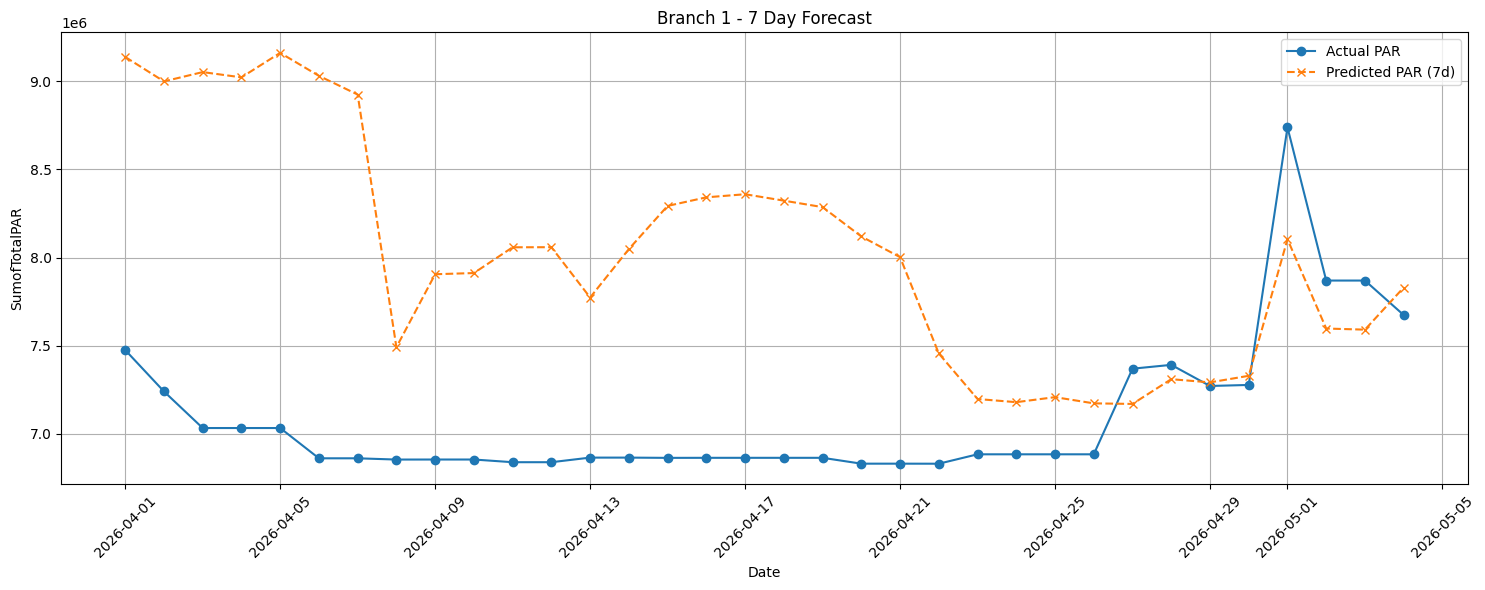


TRAINING MODEL FOR 30-DAY FORECAST
Training...
Predicting...

METRICS

CountofGroup
MAE       : 23.80
SMAPE     : 7.75%
ACCURACY  : 92.25%

CountofClientName
MAE       : 24.69
SMAPE     : 8.25%
ACCURACY  : 91.75%

CountofAccountID
MAE       : 23.80
SMAPE     : 7.75%
ACCURACY  : 92.25%

CountofCreditOfficerID
MAE       : 23.80
SMAPE     : 7.75%
ACCURACY  : 92.25%

SumofPrincipalOutstanding
MAE       : 605,385.35
SMAPE     : 7.96%
ACCURACY  : 92.04%

SumofInterestOutstanding
MAE       : 134,417.19
SMAPE     : 9.13%
ACCURACY  : 90.87%

SumofTotalPrincipalOverdue
MAE       : 263,550.95
SMAPE     : 6.10%
ACCURACY  : 93.90%

SumofTotalInterestOverdue
MAE       : 53,460.08
SMAPE     : 6.40%
ACCURACY  : 93.60%

SumofTotalPAR
MAE       : 605,385.35
SMAPE     : 7.96%
ACCURACY  : 92.04%

Generating future forecasts...


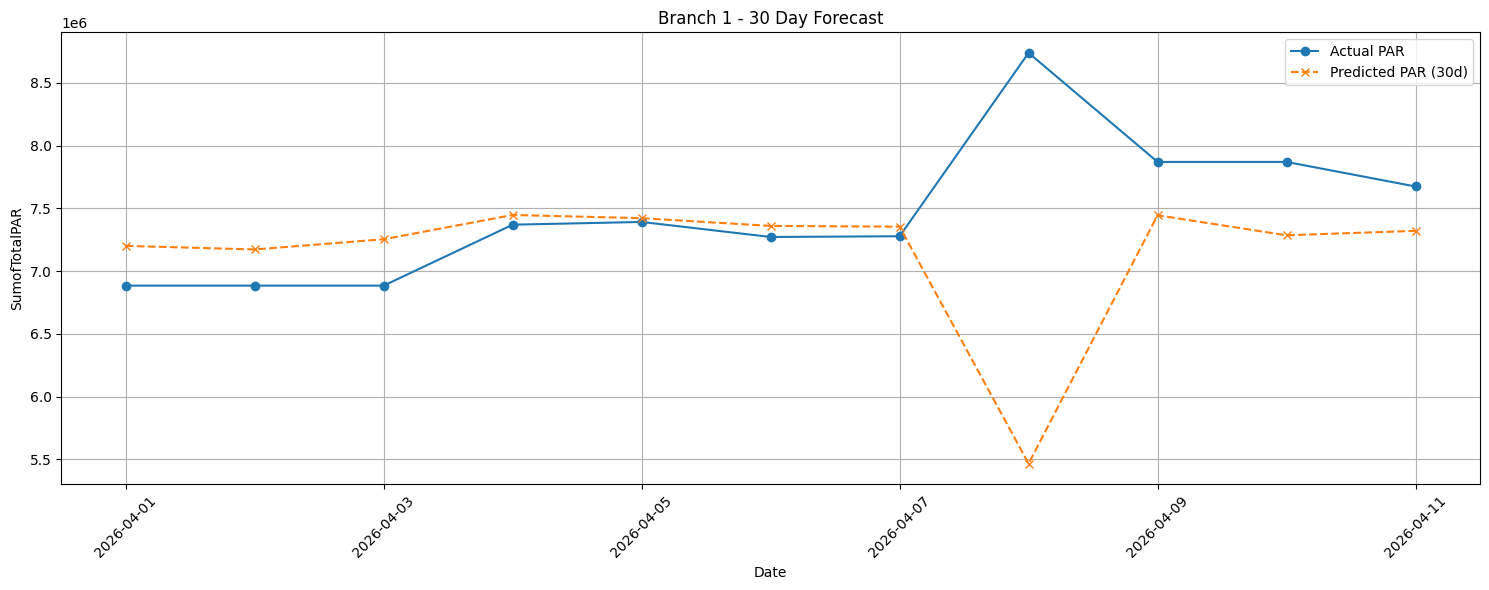


TRAINING MODEL FOR 90-DAY FORECAST
Training...


In [ ]:
# ============================================================
# MULTI-HORIZON XGBOOST FORECASTING
# ============================================================
# Forecasts:
# 1d, 7d, 30d, 90d, 180d, 365d
#
# Predicts:
# - CountofGroup
# - CountofClientName
# - CountofAccountID
# - CountofCreditOfficerID
# - SumofPrincipalOutstanding
# - SumofInterestOutstanding
# - SumofTotalPrincipalOverdue
# - SumofTotalInterestOverdue
# - SumofTotalPAR
#
# By:
# - Date
# - BranchID
#
# NO DATA LEAKAGE
# NO RECURSIVE FORECASTING
# DIRECT FORECASTING
# ============================================================

import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings("ignore")

import xgboost as xgb

from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv('/content/lag_data.csv')

# ------------------------------------------------------------
# CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = [
    re.sub(r'[^\w\s]', '', col).replace(' ', '_')
    for col in df.columns
]

# ------------------------------------------------------------
# DATE
# ------------------------------------------------------------

df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

# ------------------------------------------------------------
# DROP UNWANTED COLUMN
# ------------------------------------------------------------

if 'Unnamed_0' in df.columns:
    df = df.drop(columns=['Unnamed_0'])

# ============================================================
# 2. TARGET COLUMNS
# ============================================================

targets = [

    'CountofGroup',
    'CountofClientName',
    'CountofAccountID',
    'CountofCreditOfficerID',
    'SumofPrincipalOutstanding',
    'SumofInterestOutstanding',
    'SumofTotalPrincipalOverdue',
    'SumofTotalInterestOverdue',
    'SumofTotalPAR'

]

# ============================================================
# 3. SORT DATA
# ============================================================

df = df.sort_values(
    ['BranchID', 'Date']
).reset_index(drop=True)

# ============================================================
# 4. CALENDAR FEATURES
# ============================================================

df['dayofweek'] = df['Date'].dt.dayofweek
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter
df['year'] = df['Date'].dt.year

df['is_month_start'] = (
    df['Date'].dt.is_month_start.astype(int)
)

df['is_month_end'] = (
    df['Date'].dt.is_month_end.astype(int)
)

# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

print("Creating lag features...")

lag_days = [1, 7, 14, 30, 90]

for col in targets:

    # --------------------------------------------------------
    # LAGS
    # --------------------------------------------------------

    for lag in lag_days:

        df[f'{col}_lag{lag}'] = (

            df.groupby('BranchID')[col]
              .shift(lag)

        )

    # --------------------------------------------------------
    # ROLLING MEANS
    # IMPORTANT:
    # shift(1) BEFORE rolling
    # --------------------------------------------------------

    df[f'{col}_rollmean7'] = (

        df.groupby('BranchID')[col]
          .shift(1)
          .rolling(7)
          .mean()

    )

    df[f'{col}_rollmean30'] = (

        df.groupby('BranchID')[col]
          .shift(1)
          .rolling(30)
          .mean()

    )

    # --------------------------------------------------------
    # ROLLING STD
    # --------------------------------------------------------

    df[f'{col}_rollstd30'] = (

        df.groupby('BranchID')[col]
          .shift(1)
          .rolling(30)
          .std()

    )

    # --------------------------------------------------------
    # TRENDS
    # --------------------------------------------------------

    df[f'{col}_diff1'] = (

        df.groupby('BranchID')[col]
          .diff(1)

    )

    df[f'{col}_diff7'] = (

        df.groupby('BranchID')[col]
          .diff(7)

    )

# ============================================================
# 6. LOG TRANSFORM TARGETS
# ============================================================

print("Applying log transform...")

for col in targets:

    df[col] = np.log1p(df[col])

# ============================================================
# 7. FEATURE LIST
# ============================================================

feature_cols = []

for col in df.columns:

    if (

        'lag' in col
        or 'roll' in col
        or 'diff' in col

    ):

        feature_cols.append(col)

# ------------------------------------------------------------
# ADD CALENDAR FEATURES
# ------------------------------------------------------------

feature_cols += [

    'BranchID',
    'dayofweek',
    'weekofyear',
    'month',
    'quarter',
    'year',
    'is_month_start',
    'is_month_end'

]

# ============================================================
# 8. FORECAST HORIZONS
# ============================================================

horizons = [1, 7, 30, 90, 180, 365]

# ============================================================
# 9. TRAIN MODELS
# ============================================================

all_forecasts = []

for horizon in horizons:

    print("\n================================================")
    print(f"TRAINING MODEL FOR {horizon}-DAY FORECAST")
    print("================================================")

    df_h = df.copy()

    # --------------------------------------------------------
    # CREATE FUTURE TARGETS
    # --------------------------------------------------------

    target_cols = []

    for col in targets:

        target_col = f'{col}_target'

        df_h[target_col] = (

            df_h.groupby('BranchID')[col]
                .shift(-horizon)

        )

        target_cols.append(target_col)

    # --------------------------------------------------------
    # DROP NULLS
    # --------------------------------------------------------

    df_model = df_h.dropna(
        subset=feature_cols + target_cols
    ).copy()

    # --------------------------------------------------------
    # TRAIN / TEST SPLIT
    # --------------------------------------------------------

    train_df = df_model[
        df_model['Date'] < '2026-04-01'
    ].copy()

    test_df = df_model[
        df_model['Date'] >= '2026-04-01'
    ].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_cols]

    X_test = test_df[feature_cols]
    y_test = test_df[target_cols]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    xgb_model = xgb.XGBRegressor(

        n_estimators=2000,
        learning_rate=0.02,
        max_depth=8,

        min_child_weight=5,

        subsample=0.8,
        colsample_bytree=0.8,

        objective='reg:squarederror',

        tree_method='hist',

        random_state=42,

        n_jobs=-1

    )

    model = MultiOutputRegressor(
        xgb_model
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    print("Training...")

    model.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # PREDICT TEST
    # --------------------------------------------------------

    print("Predicting...")

    pred_logs = model.predict(X_test)

    # --------------------------------------------------------
    # INVERSE LOG
    # --------------------------------------------------------

    preds = np.expm1(pred_logs)

    actuals = np.expm1(y_test.values)

    # ========================================================
    # 10. METRICS
    # ========================================================

    def smape(actual, pred):

        return np.mean(

            2 * np.abs(pred - actual)
            /
            (np.abs(actual) + np.abs(pred) + 1e-8)

        ) * 100

    print("\nMETRICS")

    for i, col in enumerate(targets):

        mae = mean_absolute_error(
            actuals[:, i],
            preds[:, i]
        )

        smape_score = smape(
            actuals[:, i],
            preds[:, i]
        )

        accuracy = 100 - smape_score

        print(f"\n{col}")
        print(f"MAE       : {mae:,.2f}")
        print(f"SMAPE     : {smape_score:.2f}%")
        print(f"ACCURACY  : {accuracy:.2f}%")

    # ========================================================
    # 11. FUTURE FORECASTS
    # ========================================================

    print("\nGenerating future forecasts...")

    latest_rows = (

        df_model
        .sort_values('Date')
        .groupby('BranchID')
        .tail(1)
        .copy()

    )

    future_X = latest_rows[feature_cols]

    future_logs = model.predict(future_X)

    future_preds = np.expm1(future_logs)

    forecast_date = (

        latest_rows['Date']
        + pd.Timedelta(days=horizon)

    )

    # --------------------------------------------------------
    # STORE FORECASTS
    # --------------------------------------------------------

    for idx in range(len(latest_rows)):

        row = {

            'BranchID':
            latest_rows.iloc[idx]['BranchID'],

            'ForecastDate':
            forecast_date.iloc[idx],

            'HorizonDays':
            horizon

        }

        for t, col in enumerate(targets):

            row[col] = future_preds[idx][t]

        all_forecasts.append(row)

    # ========================================================
    # 12. VISUALIZE BRANCH 1
    # ========================================================

    branch_id = 1

    mask = (
        test_df['BranchID'] == branch_id
    )

    plot_dates = test_df.loc[
        mask,
        'Date'
    ]

    actual_plot = actuals[
        mask.values,
        8
    ]

    pred_plot = preds[
        mask.values,
        8
    ]

    plt.figure(figsize=(15, 6))

    plt.plot(

        plot_dates,
        actual_plot,

        label='Actual PAR',

        marker='o'

    )

    plt.plot(

        plot_dates,
        pred_plot,

        label=f'Predicted PAR ({horizon}d)',

        linestyle='--',

        marker='x'

    )

    plt.title(

        f'Branch {branch_id} - '
        f'{horizon} Day Forecast'

    )

    plt.ylabel('SumofTotalPAR')

    plt.xlabel('Date')

    plt.legend()

    plt.grid(True)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ============================================================
# 13. FINAL FORECAST DATAFRAME
# ============================================================

forecast_df = pd.DataFrame(all_forecasts)

# ============================================================
# 14. SAVE
# ============================================================

forecast_df.to_csv(
    'forecasted.csv',
    index=False
)

print("\n================================================")
print("FORECAST FILE SAVED")
print("================================================")

print("\nforecasted.csv")

print("\nSample Forecasts:\n")

print(forecast_df.head())

# ============================================================
# 15. OPTIONAL:
# FEATURE IMPORTANCE FOR ONE MODEL
# ============================================================

print("\nShowing feature importance...")

booster = model.estimators_[0]

importance = pd.DataFrame({

    'Feature': feature_cols,

    'Importance':
    booster.feature_importances_

})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(12, 10))

plt.barh(

    importance['Feature'][:20][::-1],

    importance['Importance'][:20][::-1]

)

plt.title('Top 20 Feature Importances')

plt.tight_layout()

plt.show()